# Approach 1 — Version 4: Improved SVM + Random Masking

Builds on the **improved** model (all 5 improvements) and adds **random token masking**:

| Component | Source |
|---|---|
| Teen code normalization | Improved (V2) |
| Multi-label augmentation | Improved (V2) |
| Handcrafted features | Improved (V2) |
| Logistic Regression | Improved (V2) |
| Per-class threshold tuning | Improved (V2) |
| **Random token masking** | New in V4 |

**Prerequisite:** Run `data_preparation/data_split.ipynb` first.

In [1]:
#!pip install scikit-learn scipy numpy pandas matplotlib seaborn joblib --quiet

In [2]:
import json
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
from scipy.sparse import hstack, vstack as sp_vstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, hamming_loss, accuracy_score, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

DATA_DIR = '../final_data'

## 1. Load Pre-split Data

In [3]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            texts.append(item['text'])
            labels.append(item['cats'])
    return texts, labels

train_texts, train_labels = load_jsonl(f'{DATA_DIR}/train.jsonl')
val_texts,   val_labels   = load_jsonl(f'{DATA_DIR}/val.jsonl')
test_texts,  test_labels  = load_jsonl(f'{DATA_DIR}/test.jsonl')

mlb    = joblib.load(f'{DATA_DIR}/mlb.joblib')
y_val  = mlb.transform(val_labels)
y_test = mlb.transform(test_labels)

print(f'Train : {len(train_texts):4d} samples')
print(f'Val   : {len(val_texts):4d} samples')
print(f'Test  : {len(test_texts):4d} samples')
print(f'Labels: {len(mlb.classes_)} classes')

Train : 3605 samples
Val   :  454 samples
Test  :  450 samples
Labels: 32 classes


## 2. Teen Code Normalization

In [ ]:
TEEN_CODE = {
    'k'   : 'không', 'ko'  : 'không', 'kh' : 'không',
    'khum': 'không', 'kum' : 'không',
    'đc'  : 'được',  'dc'  : 'được',
    'vs'  : 'với',
    'b'   : 'bạn',
    'sốp' : 'shop',  'sốc' : 'shop',
    'ck'  : 'chuyển khoản',
    'r'   : 'rồi',   'rui' : 'rồi',
    'nha' : 'nhé',   'nhen': 'nhé',
    'sp'  : 'sản phẩm',
    'mn'  : 'mọi người',
    'e'   : 'em',    'a'   : 'anh',
    'v'   : 'vậy',  'z' :   'vậy',
    'dchi' : 'địa chỉ',
    'q'     : 'quận', 'tp'   : 'thành phố',
    'bnh'   : 'bao nhiêu',
    'b'     : 'bạn',
}

def normalize(text):
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = text.split()
    result = []
    for token in tokens:
        if re.match(r'^[a-z0-9\-]+$', token) and token not in TEEN_CODE:
            result.append(token)
        else:
            result.append(TEEN_CODE.get(token, token))
    return ' '.join(result)

norm_train = [normalize(t) for t in train_texts]
norm_val   = [normalize(t) for t in val_texts]
norm_test  = [normalize(t) for t in test_texts]
print('Normalization applied.')

Normalization applied.


## 3. Multi-label Augmentation

In [5]:
multi_idx    = [i for i, l in enumerate(train_labels) if len(l) > 1]
extra_texts  = [norm_train[i]  for i in multi_idx] * 2
extra_labels = [train_labels[i] for i in multi_idx] * 2

aug_texts  = norm_train + extra_texts
aug_labels = train_labels + extra_labels

print(f'Original train : {len(norm_train)}')
print(f'Multi-label    : {len(multi_idx)}')
print(f'Augmented total: {len(aug_texts)}')

Original train : 3605
Multi-label    : 387
Augmented total: 4379


## 4. Random Token Masking

Randomly drops tokens with probability `mask_prob=0.15` to create one additional masked copy of the augmented training set.

**Why:** Prevents the model from over-relying on specific trigger words; makes the calibrated LR probabilities more robust at lower confidence thresholds.

In [6]:
MASK_PROB = 0.15

def random_mask(text: str, mask_prob: float = MASK_PROB, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    tokens = text.split()
    kept = [t for t in tokens if rng.random() > mask_prob]
    return ' '.join(kept) if kept else text

rng = np.random.default_rng(42)
masked_texts = [random_mask(t, rng=rng) for t in aug_texts]

masked_train_texts  = aug_texts + masked_texts
masked_train_labels = aug_labels + aug_labels
y_masked = mlb.transform(masked_train_labels)

print(f'Augmented train : {len(aug_texts)}')
print(f'After masking   : {len(masked_train_texts)} (1 masked copy added)')
print(f'\nExample:')
print(f'  Original: {aug_texts[0]}')
print(f'  Masked  : {masked_texts[0]}')

Augmented train : 4379
After masking   : 8758 (1 masked copy added)

Example:
  Original: chị ưu tiên gửi batch mới nhất giúp em.
  Masked  : chị ưu tiên gửi mới nhất giúp


## 5. Feature Extraction

In [7]:
def handcrafted_features(texts):
    rows = []
    for t in texts:
        rows.append([
            len(t.split()),
            len(t),
            t.count('?'),
            int(bool(re.search(r'0[3-9]\d{8}', t))),
            int(bool(re.search(r'\d+', t))),
            int('\u1ea1' in t or 'nh\u00e9' in t or 'nha' in t),
        ])
    return sp.csr_matrix(rows, dtype=np.float32)

tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    max_features=30_000, min_df=2, sublinear_tf=True
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_features=20_000, min_df=2, sublinear_tf=True
)

X_train_word = tfidf_word.fit_transform(masked_train_texts)
X_train_char = tfidf_char.fit_transform(masked_train_texts)
X_train_feat = hstack([X_train_word, X_train_char, handcrafted_features(masked_train_texts)])

X_val_feat  = hstack([tfidf_word.transform(norm_val),  tfidf_char.transform(norm_val),  handcrafted_features(norm_val)])
X_test_feat = hstack([tfidf_word.transform(norm_test), tfidf_char.transform(norm_test), handcrafted_features(norm_test)])

print(f'Train feature matrix: {X_train_feat.shape}')

Train feature matrix: (8758, 24208)


## 6. Train Logistic Regression (OvR)

In [8]:
best_c, best_val_f1 = None, 0.0

for C in [0.1, 1.0, 10.0]:
    clf = OneVsRestClassifier(
        LogisticRegression(C=C, class_weight='balanced', max_iter=1000, solver='lbfgs'),
        n_jobs=1
    )
    clf.fit(X_train_feat, y_masked)
    y_pred_val = clf.predict(X_val_feat)

    macro_f1 = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    micro_f1 = f1_score(y_val, y_pred_val, average='micro', zero_division=0)
    print(f'  C={C:5.1f}  |  Val Macro-F1: {macro_f1:.4f}  |  Val Micro-F1: {micro_f1:.4f}')

    if macro_f1 > best_val_f1:
        best_val_f1, best_c = macro_f1, C

print(f'\nBest C = {best_c}  (Val Macro-F1 = {best_val_f1:.4f})')

  C=  0.1  |  Val Macro-F1: 0.6891  |  Val Micro-F1: 0.6925
  C=  1.0  |  Val Macro-F1: 0.8129  |  Val Micro-F1: 0.8266
  C= 10.0  |  Val Macro-F1: 0.8472  |  Val Micro-F1: 0.8536

Best C = 10.0  (Val Macro-F1 = 0.8472)


## 7. Per-class Threshold Tuning

In [9]:
tuning_model = OneVsRestClassifier(
    LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
    n_jobs=1
)
tuning_model.fit(X_train_feat, y_masked)
val_proba = tuning_model.predict_proba(X_val_feat)

thresholds = []
for i, cls in enumerate(mlb.classes_):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.95, 0.05):
        preds = (val_proba[:, i] >= t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds.append(best_t)

df_thresh = pd.DataFrame({'Class': mlb.classes_, 'Threshold': thresholds})
print(df_thresh.to_string(index=False))

                    Class  Threshold
                  Goodbye       0.65
              add_product       0.70
                    agree       0.65
              agree_order       0.55
          ask_final_price       0.75
         ask_find_product       0.30
         ask_gift_package       0.50
                ask_legit       0.75
         ask_order_status       0.75
      ask_order_wait_time       0.40
       ask_payment_method       0.30
 ask_product_availability       0.80
        ask_product_image       0.25
         ask_product_info       0.40
        ask_product_price       0.65
   ask_product_suggestion       0.55
         ask_shipping_fee       0.25
            ask_shop_info       0.40
               buy_thanks       0.85
  complain_shipping_issue       0.50
         confirm_received       0.55
          customer_reject       0.65
delivery_time_requirement       0.60
       get_product_direct       0.90
             give_product       0.35
                 greeting       0.65
 

In [10]:
# Retrain on train + val combined
X_val_merge = hstack([tfidf_word.transform(norm_val), tfidf_char.transform(norm_val), handcrafted_features(norm_val)])
X_trainval  = sp_vstack([X_train_feat, X_val_merge])
y_trainval  = np.vstack([y_masked, y_val])

final_model = OneVsRestClassifier(
    LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
    n_jobs=1
)
final_model.fit(X_trainval, y_trainval)
print(f'Final model trained on train+val ({len(y_trainval)} samples).')

Final model trained on train+val (9212 samples).


## 8. Evaluate on Test Set

In [11]:
test_proba   = final_model.predict_proba(X_test_feat)
y_pred_tuned = (test_proba >= np.array(thresholds)).astype(int)

macro_f1   = f1_score(y_test, y_pred_tuned, average='macro',  zero_division=0)
micro_f1   = f1_score(y_test, y_pred_tuned, average='micro',  zero_division=0)
h_loss     = hamming_loss(y_test, y_pred_tuned)
subset_acc = accuracy_score(y_test, y_pred_tuned)

print('=' * 55)
print('TEST RESULTS — V4: Improved LR + Random Masking')
print('=' * 55)
print(f'Macro-F1        : {macro_f1:.4f}')
print(f'Micro-F1        : {micro_f1:.4f}')
print(f'Hamming Loss    : {h_loss:.4f}')
print(f'Subset Accuracy : {subset_acc:.4f}')

TEST RESULTS — V4: Improved LR + Random Masking
Macro-F1        : 0.8623
Micro-F1        : 0.8702
Hamming Loss    : 0.0092
Subset Accuracy : 0.7533


In [12]:
print(classification_report(y_test, y_pred_tuned, target_names=mlb.classes_, zero_division=0))

                           precision    recall  f1-score   support

                  Goodbye       0.83      0.91      0.87        11
              add_product       1.00      0.91      0.95        11
                    agree       1.00      0.75      0.86        20
              agree_order       0.89      0.94      0.91        17
          ask_final_price       0.75      0.50      0.60         6
         ask_find_product       1.00      0.25      0.40         4
         ask_gift_package       0.86      1.00      0.92         6
                ask_legit       1.00      0.90      0.95        10
         ask_order_status       0.96      0.96      0.96        23
      ask_order_wait_time       0.92      0.92      0.92        12
       ask_payment_method       0.85      1.00      0.92        17
 ask_product_availability       0.81      0.85      0.83        26
        ask_product_image       0.76      1.00      0.87        13
         ask_product_info       0.79      0.92      0.85     

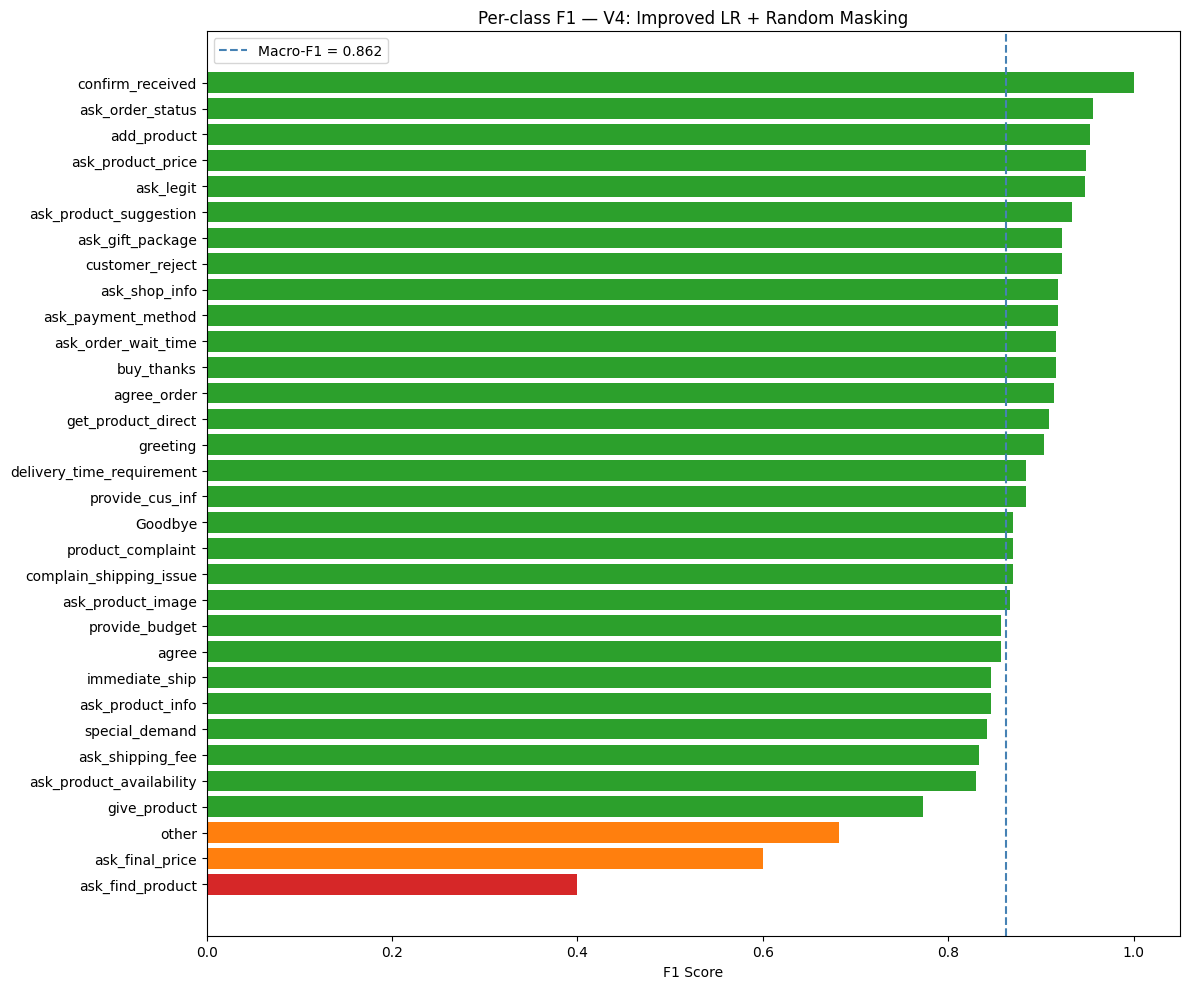

In [13]:
per_class_f1 = f1_score(y_test, y_pred_tuned, average=None, zero_division=0)
df_f1 = pd.DataFrame({'Label': mlb.classes_, 'F1': per_class_f1}).sort_values('F1', ascending=True)

colors = ['#d62728' if f < 0.5 else '#ff7f0e' if f < 0.7 else '#2ca02c' for f in df_f1['F1']]
plt.figure(figsize=(12, 10))
plt.barh(df_f1['Label'], df_f1['F1'], color=colors)
plt.axvline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5, label=f'Macro-F1 = {macro_f1:.3f}')
plt.xlabel('F1 Score')
plt.title('Per-class F1 — V4: Improved LR + Random Masking')
plt.legend()
plt.tight_layout()
plt.savefig('results/v4_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Compare with V2 (Improved without Masking)

In [14]:
try:
    with open('results/metrics_improved.json', 'r', encoding='utf-8') as f:
        v2 = json.load(f)
except FileNotFoundError:
    print('V2 metrics not found. Run approach1_svm_improved.ipynb first.')
    v2 = None

if v2:
    df_cmp = pd.DataFrame({
        'Metric'  : ['Macro-F1', 'Micro-F1', 'Hamming Loss', 'Subset Accuracy'],
        'V2 (Improved)': [v2['macro_f1'], v2['micro_f1'], v2['hamming_loss'], v2['subset_accuracy']],
        'V4 (+Masking)': [round(macro_f1, 4), round(micro_f1, 4), round(h_loss, 4), round(subset_acc, 4)],
    })
    df_cmp['Delta'] = (df_cmp['V4 (+Masking)'] - df_cmp['V2 (Improved)']).apply(
        lambda x: f'+{x:.4f}' if x > 0 else f'{x:.4f}'
    )
    display(df_cmp)

,Metric,V2 (Improved),V4 (+Masking),Delta
0,Macro-F1,0.8695,0.8623,-0.0072
1,Micro-F1,0.8727,0.8702,-0.0025
2,Hamming Loss,0.0090,0.0092,+0.0002
3,Subset Accuracy,0.7600,0.7533,-0.0067


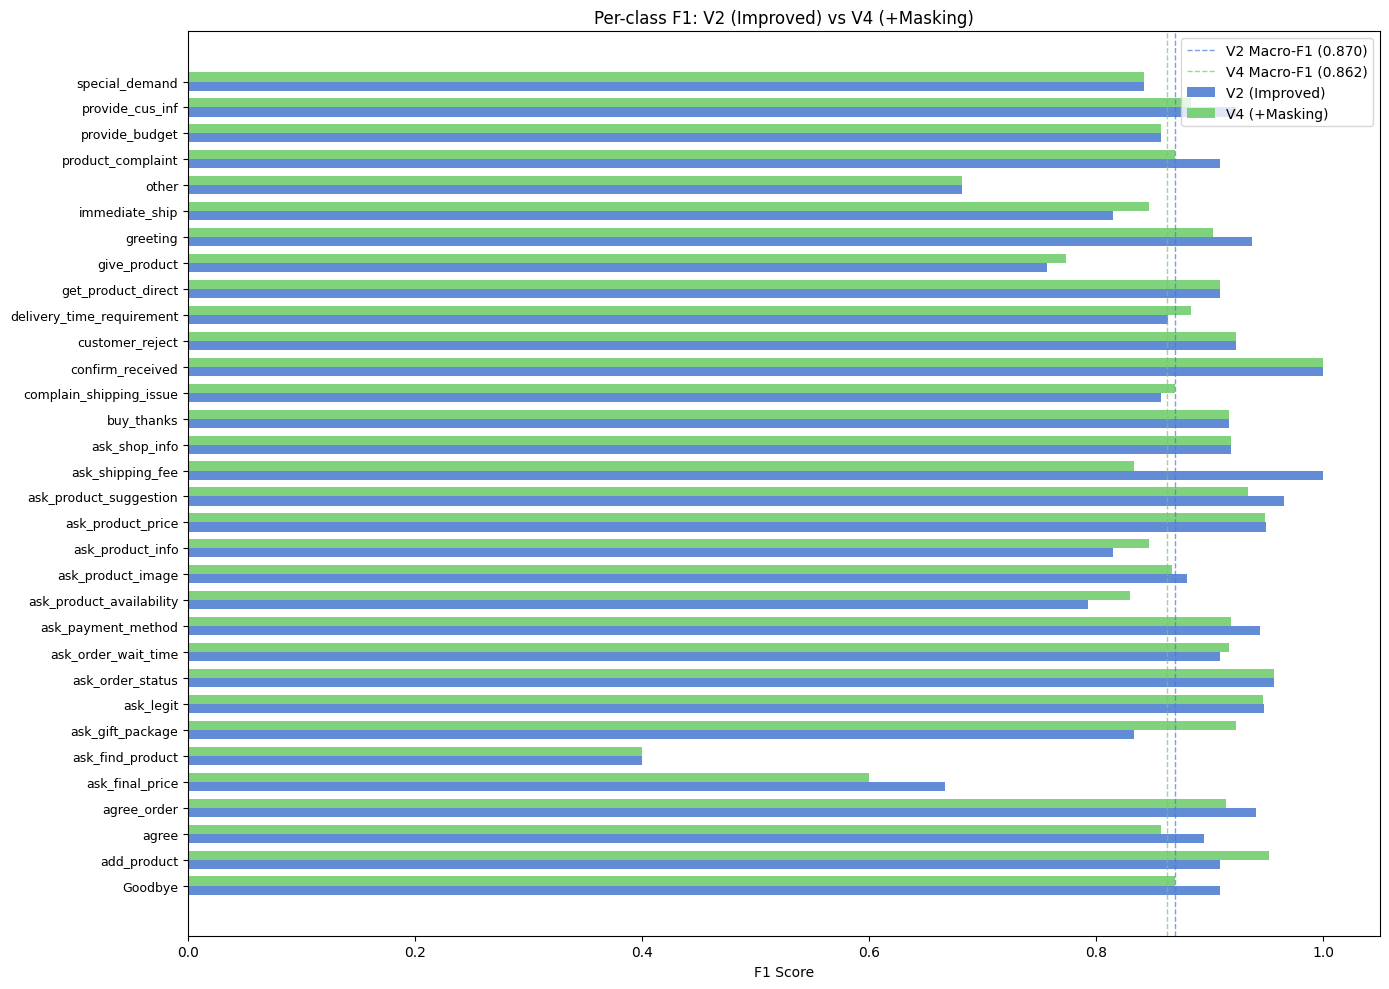

In [15]:
if v2:
    per_class_f1_v2 = np.array([v2['per_class_f1'][c] for c in mlb.classes_])
    x = np.arange(len(mlb.classes_))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.barh(x - width/2, per_class_f1_v2,  width, label='V2 (Improved)',       color='#4878d0', alpha=0.85)
    ax.barh(x + width/2, per_class_f1,     width, label='V4 (+Masking)',        color='#6acc65', alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(mlb.classes_, fontsize=9)
    ax.axvline(v2['macro_f1'], color='#4878d0', linestyle='--', linewidth=1, alpha=0.7,
               label=f'V2 Macro-F1 ({v2["macro_f1"]:.3f})')
    ax.axvline(macro_f1, color='#6acc65', linestyle='--', linewidth=1, alpha=0.7,
               label=f'V4 Macro-F1 ({macro_f1:.3f})')
    ax.set_xlabel('F1 Score')
    ax.set_title('Per-class F1: V2 (Improved) vs V4 (+Masking)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/v4_comparison_per_class_f1.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9b. Learning Curve

     10% ( 875) — Train: 0.9966  Val: 0.7296
     20% (1751) — Train: 0.9925  Val: 0.8072
     30% (2627) — Train: 0.9883  Val: 0.8377
     40% (3503) — Train: 0.9861  Val: 0.8456
     50% (4379) — Train: 0.9869  Val: 0.8466
     60% (5254) — Train: 0.9879  Val: 0.8485
     70% (6130) — Train: 0.9878  Val: 0.8458
     80% (7006) — Train: 0.9884  Val: 0.8470
     90% (7882) — Train: 0.9871  Val: 0.8482
    100% (8758) — Train: 0.9872  Val: 0.8472


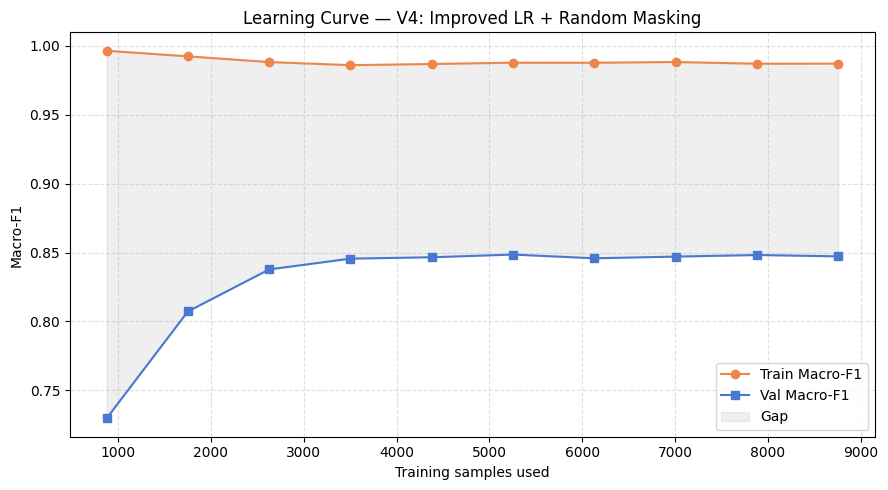


Final gap (Train - Val): +0.1400


In [16]:
fractions   = np.linspace(0.1, 1.0, 10)
train_f1s, val_f1s, train_sizes = [], [], []
n_total = X_train_feat.shape[0]

for frac in fractions:
    n = max(1, int(n_total * frac))
    clf = OneVsRestClassifier(
        LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, solver='lbfgs'),
        n_jobs=1
    )
    clf.fit(X_train_feat[:n], y_masked[:n])
    train_f1s.append(f1_score(y_masked[:n], clf.predict(X_train_feat[:n]), average='macro', zero_division=0))
    val_f1s.append(  f1_score(y_val,        clf.predict(X_val_feat),       average='macro', zero_division=0))
    train_sizes.append(n)
    print(f'  {frac*100:5.0f}% ({n:4d}) — Train: {train_f1s[-1]:.4f}  Val: {val_f1s[-1]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_f1s, 'o-', color='#ee854a', label='Train Macro-F1')
ax.plot(train_sizes, val_f1s,   's-', color='#4878d0', label='Val Macro-F1')
ax.fill_between(train_sizes, train_f1s, val_f1s, alpha=0.12, color='gray', label='Gap')
ax.set_xlabel('Training samples used')
ax.set_ylabel('Macro-F1')
ax.set_title('Learning Curve — V4: Improved LR + Random Masking')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/v4_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFinal gap (Train - Val): {train_f1s[-1] - val_f1s[-1]:+.4f}')

## 10. Save Model and Results

In [17]:
joblib.dump(final_model, 'results/v4_model.joblib')
joblib.dump(tfidf_word,  'results/v4_tfidf_word.joblib')
joblib.dump(tfidf_char,  'results/v4_tfidf_char.joblib')

metrics = {
    'approach'        : 'Improved LR + Random Masking (V4)',
    'best_C'          : best_c,
    'mask_prob'       : MASK_PROB,
    'thresholds'      : {k: round(float(v), 4) for k, v in zip(mlb.classes_, thresholds)},
    'macro_f1'        : round(macro_f1,   4),
    'micro_f1'        : round(micro_f1,   4),
    'hamming_loss'    : round(h_loss,     4),
    'subset_accuracy' : round(subset_acc, 4),
    'per_class_f1'    : {k: round(float(v), 4) for k, v in zip(mlb.classes_, per_class_f1)}
}

with open('results/v4_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved to approach1/results/: v4_model.joblib, v4_tfidf_*.joblib, v4_metrics.json')

Saved to approach1/results/: v4_model.joblib, v4_tfidf_*.joblib, v4_metrics.json


## 11. Test Custom Input

In [18]:
import joblib, json, re, datetime
import numpy as np
import scipy.sparse as sp
from scipy.sparse import hstack

_model      = joblib.load('results/v4_model.joblib')
_tfidf_word = joblib.load('results/v4_tfidf_word.joblib')
_tfidf_char = joblib.load('results/v4_tfidf_char.joblib')
_mlb        = joblib.load('../final_data/mlb.joblib')

with open('results/v4_metrics.json', encoding='utf-8') as f:
    _thresholds = np.array(list(json.load(f)['thresholds'].values()))

_prediction_log = []

def predict(text: str, top_k: int = 3):
    norm = normalize(text)
    feat = hstack([_tfidf_word.transform([norm]), _tfidf_char.transform([norm]), handcrafted_features([norm])])
    proba     = _model.predict_proba(feat)[0]
    predicted = tuple(cls for cls, p, t in zip(_mlb.classes_, proba, _thresholds) if p >= t)
    ranked    = sorted(zip(_mlb.classes_, proba), key=lambda x: -x[1])

    _prediction_log.append({
        'timestamp' : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input'     : text,
        'normalized': norm,
        'predicted' : list(predicted),
        'top_proba' : {label: round(float(p), 4) for label, p in ranked[:top_k]},
    })

    print(f'Input     : {text}')
    print(f'Normalized: {norm}')
    print(f'Predicted : {list(predicted) if predicted else "[none above threshold]"}')
    print(f'Top {top_k} probabilities:')
    for label, prob in ranked[:top_k]:
        marker = ' <--' if label in predicted else ''
        print(f'  {label:<35} {prob:.3f}{marker}')

print('predict() ready.')

predict() ready.


In [26]:
# ── Change this text and re-run ───────────────────────────────────────────────────
predict('sốp ship về ngõ 20 Cát Linh cho em nhé, hết bnh shop nhỉ ')

Input     : sốp ship về ngõ 20 Cát Linh cho em nhé, hết bnh shop nhỉ 
Normalized: shop ship về ngõ 20 cát linh cho em nhé, hết bnh shop nhỉ
Predicted : ['ask_shipping_fee', 'provide_cus_inf']
Top 3 probabilities:
  ask_shipping_fee                    0.265 <--
  agree_order                         0.203
  provide_cus_inf                     0.178 <--


In [20]:
samples = ['shop ơi', 'bao g có hàng thế ạ', 'cho e đặt màu xanh với ạ', 'giá con này bao nhiêu vậy shop']
for text in samples:
    print('-' * 55)
    predict(text, top_k=2)
print('-' * 55)

-------------------------------------------------------
Input     : shop ơi
Normalized: shop ơi
Predicted : ['greeting']
Top 2 probabilities:
  greeting                            0.999 <--
  ask_product_availability            0.037
-------------------------------------------------------
Input     : bao g có hàng thế ạ
Normalized: bao g có hàng thế ạ
Predicted : ['ask_order_wait_time']
Top 2 probabilities:
  ask_order_wait_time                 0.997 <--
  ask_order_status                    0.340
-------------------------------------------------------
Input     : cho e đặt màu xanh với ạ
Normalized: cho em đặt màu xanh với ạ
Predicted : ['agree_order']
Top 2 probabilities:
  agree_order                         0.999 <--
  ask_product_image                   0.131
-------------------------------------------------------
Input     : giá con này bao nhiêu vậy shop
Normalized: giá con này bao nhiêu vậy shop
Predicted : ['ask_product_price']
Top 2 probabilities:
  ask_product_price         

## 12. Prediction History Log

In [21]:
def show_log(n=None):
    entries = _prediction_log if n is None else _prediction_log[-n:]
    if not entries:
        print('Log is empty — run predict() first.')
        return
    print(f'{"#":<4} {"Timestamp":<20} {"Input":<40} {"Predicted"}')
    print('-' * 100)
    for i, e in enumerate(entries):
        idx   = len(_prediction_log) - len(entries) + i + 1
        inp   = e['input'][:38] + '..' if len(e['input']) > 40 else e['input']
        preds = ', '.join(e['predicted']) if e['predicted'] else '[none]'
        print(f'{idx:<4} {e["timestamp"]:<20} {inp:<40} {preds}')
    print(f'\nTotal entries: {len(_prediction_log)}')

show_log()

#    Timestamp            Input                                    Predicted
----------------------------------------------------------------------------------------------------
1    2026-06-07 22:25:11  sốp ơi còn hàng con ferrari k ạ          ask_product_availability
2    2026-06-07 22:25:11  shop ơi                                  greeting
3    2026-06-07 22:25:11  bao g có hàng thế ạ                      ask_order_wait_time
4    2026-06-07 22:25:11  cho e đặt màu xanh với ạ                 agree_order
5    2026-06-07 22:25:11  giá con này bao nhiêu vậy shop           ask_product_price

Total entries: 5


In [22]:
LOG_PATH = 'results/v4_prediction_log.jsonl'

def save_log(path=LOG_PATH, mode='append'):
    if not _prediction_log:
        print('Nothing to save.')
        return
    if mode == 'append':
        existing = set()
        try:
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    e = json.loads(line)
                    existing.add((e['timestamp'], e['input']))
        except FileNotFoundError:
            pass
        new = [e for e in _prediction_log if (e['timestamp'], e['input']) not in existing]
        with open(path, 'a', encoding='utf-8') as f:
            for e in new:
                json.dump(e, f, ensure_ascii=False); f.write('\n')
        print(f'Appended {len(new)} entries → {path}')
    else:
        with open(path, 'w', encoding='utf-8') as f:
            for e in _prediction_log:
                json.dump(e, f, ensure_ascii=False); f.write('\n')
        print(f'Saved {len(_prediction_log)} entries → {path}')

def clear_log():
    count = len(_prediction_log)
    _prediction_log.clear()
    print(f'Cleared {count} entries.')

print('save_log() / clear_log() ready.')

save_log() / clear_log() ready.
